**Childhood Overweight: Global Trends and Gender Differences**

---

## **Introduction**

Childhood overweight has become an increasingly important global public health issue. Rising levels of overweight among children are linked to long-term health risks, including obesity, cardiovascular disease, and diabetes later in life.

This report explores childhood overweight using UNICEF data, with a particular focus on geographic distribution, the countries most affected, changes over time, and gender differences.

The analysis is based on the indicator **Weight-for-height >+2 SD (overweight), Modeled Estimates** and aims to show that childhood overweight is not only a local concern, but a widespread and growing global issue.

In [39]:
## LIBRARIES IMPORT
import pandas as pd
import numpy as np
from plotnine import *

In [40]:
## DATA CLEANING
df = pd.read_csv("unicef_indicator_1.csv")
df.head()

,country,alpha_2_code,alpha_3_code,numeric_code,indicator,time_period,obs_value,sex,unit_multiplier,unit_of_measure,observation_status,observation_confidentaility,time_period_activity_related_to_when_the_data_are_collected,current_age
0,Afghanistan,AF,AFG,4,"Weight-for-height >+2 SD (overweight), Modeled...",2000,4.5,Female,Units,%,Modelled,NaN,Other,Under 5 years old
1,Afghanistan,AF,AFG,4,"Weight-for-height >+2 SD (overweight), Modeled...",2001,4.6,Female,Units,%,Modelled,NaN,Other,Under 5 years old
2,Afghanistan,AF,AFG,4,"Weight-for-height >+2 SD (overweight), Modeled...",2002,4.6,Female,Units,%,Modelled,NaN,Other,Under 5 years old
3,Afghanistan,AF,AFG,4,"Weight-for-height >+2 SD (overweight), Modeled...",2003,4.6,Female,Units,%,Modelled,NaN,Other,Under 5 years old
4,Afghanistan,AF,AFG,4,"Weight-for-height >+2 SD (overweight), Modeled...",2004,4.6,Female,Units,%,Modelled,NaN,Other,Under 5 years old


In [41]:
## Data Cleaning
overweight_df = df[['country', 'alpha_3_code', 'indicator', 'time_period', 'obs_value', 'sex']].copy()

overweight_df = overweight_df.rename(columns={
    'time_period': 'year',
    'obs_value': 'value'
})

overweight_df = overweight_df.dropna(subset=['value'])

overweight_df.head()

,country,alpha_3_code,indicator,year,value,sex
0,Afghanistan,AFG,"Weight-for-height >+2 SD (overweight), Modeled...",2000,4.5,Female
1,Afghanistan,AFG,"Weight-for-height >+2 SD (overweight), Modeled...",2001,4.6,Female
2,Afghanistan,AFG,"Weight-for-height >+2 SD (overweight), Modeled...",2002,4.6,Female
3,Afghanistan,AFG,"Weight-for-height >+2 SD (overweight), Modeled...",2003,4.6,Female
4,Afghanistan,AFG,"Weight-for-height >+2 SD (overweight), Modeled...",2004,4.6,Female


In [42]:
## DATA CLEANING
df_total_2024 = overweight_df[
    (overweight_df['year'] == 2024) &
    (overweight_df['sex'] == 'Total')
].copy()

df_total_2024.head()

,country,alpha_3_code,indicator,year,value,sex
74,Afghanistan,AFG,"Weight-for-height >+2 SD (overweight), Modeled...",2024,4.4,Total
149,Albania,ALB,"Weight-for-height >+2 SD (overweight), Modeled...",2024,16.7,Total
224,Algeria,DZA,"Weight-for-height >+2 SD (overweight), Modeled...",2024,13.3,Total
299,Angola,AGO,"Weight-for-height >+2 SD (overweight), Modeled...",2024,4.7,Total
374,Argentina,ARG,"Weight-for-height >+2 SD (overweight), Modeled...",2024,14.3,Total


## **Global Distribution of Childhood Overweight (2024)**

The map illustrates the global distribution of childhood overweight prevalence in 2024, highlighting significant regional differences.

Higher prevalence levels are concentrated in specific regions, most notably in **Australia**, which stands out as the country with the highest recorded rate. Elevated levels can also be observed in parts of **Latin America**, **North Africa**, and **Eastern Europe**, indicating that childhood overweight is not limited to a single region or level of economic development.

In contrast, many countries across **Sub-Saharan Africa** and parts of **South and Southeast Asia** display lower prevalence rates. However, this does not necessarily imply the absence of risk, but rather reflects differing stages of nutritional and economic transition.

It is important to note that some countries appear without colour due to missing data for 2024. Despite these gaps, the map provides a clear overview of the global landscape of childhood overweight.

Overall, the visualisation reinforces the idea that **childhood overweight is a widespread and growing global issue**, with notable geographic disparities that require targeted public health responses.

In [43]:
import plotly.express as px
## MAP GRAPH
map_df = overweight_df[
    (overweight_df['year'] == 2024) &
    (overweight_df['sex'] == 'Total')
].copy()

## GRAPH SOURCES
fig = px.choropleth(
    map_df,
    locations='alpha_3_code',
    color='value',
    hover_name='country',
    color_continuous_scale='YlOrRd',
    projection='natural earth',
    title='<b>Global Distribution of Childhood Overweight (2024)</b>',
)

## TOOLTIP CLEAN
fig.update_traces(
    hovertemplate=
    "<b>%{hovertext}</b><br>" +
    "Overweight: %{z:.1f}%<br>" +
    "<extra></extra>"
)

fig.update_layout(
    width=750,
    height=650,
    margin=dict(l=10, r=10, t=70, b=10),

    title={
        'x': 0.5,
        'xanchor': 'center',
        'font': {'size': 25, 'color': 'black'}
    },

    ## ALL TEXT ARE BLACK
    font=dict(
        size=14,
        color='black'
    ),

    coloraxis_colorbar=dict(
        title=dict(
            text='<b>Overweight (%)</b>',
            side='right'
        ),
        len=0.6,
        thickness=15
    ),

    geo=dict(
        showframe=False,
        showcoastlines=False,
        bgcolor='white'
    )
)

fig.show()

In [44]:
## Following Tableau Countries to be precise
countries_tableau = [
    'Australia',
    'Turks and Caicos Islands',
    'Ukraine',
    'Albania',
    'Bosnia and Herzegovina',
    'Armenia',
    'Serbia',
    'Syrian Arab Republic',
    'Montenegro',
    'Libyan Arab Jamahiriya'
]
## QUICK CONTROL
df_filtered = df_total_2024[
    df_total_2024['country'].isin(countries_tableau)
].copy()

top10 = df_filtered.sort_values('value', ascending=True)

top10[['country', 'value']]

,country,value
6299,Libyan Arab Jamahiriya,4.7
7274,Montenegro,8.6
10574,Syrian Arab Republic,11.0
9674,Serbia,12.2
449,Armenia,12.9
1349,Bosnia and Herzegovina,13.0
11549,Ukraine,16.0
149,Albania,16.7
11249,Turks and Caicos Islands,18.3
524,Australia,26.4


## **Countries Most Affected by Childhood Overweight**

This analysis focuses on a selected group of countries identified in the initial dashboard.

The selection includes countries with notably high levels of childhood overweight in 2024, such as Australia, Turks and Caicos Islands, Ukraine, and Albania, as well as several countries from Eastern Europe and North Africa.

**Australia** clearly stands out, with a prevalence exceeding 26%, making it the most affected country within this group. Other countries, including **Turks and Caicos Islands and Ukraine**, also show relatively high levels, above 15%.

Countries such as Bosnia and Herzegovina, Armenia, and Serbia fall into a mid-range category, while Montenegro and Libya report lower—but still significant—levels of childhood overweight.

Although this is not a complete global ranking, this selection highlights how childhood overweight affects a diverse range of countries, including both high-income nations and developing regions.

Overall, the comparison demonstrates that childhood overweight is a **widespread issue** that is not limited to a single geographic or economic context.

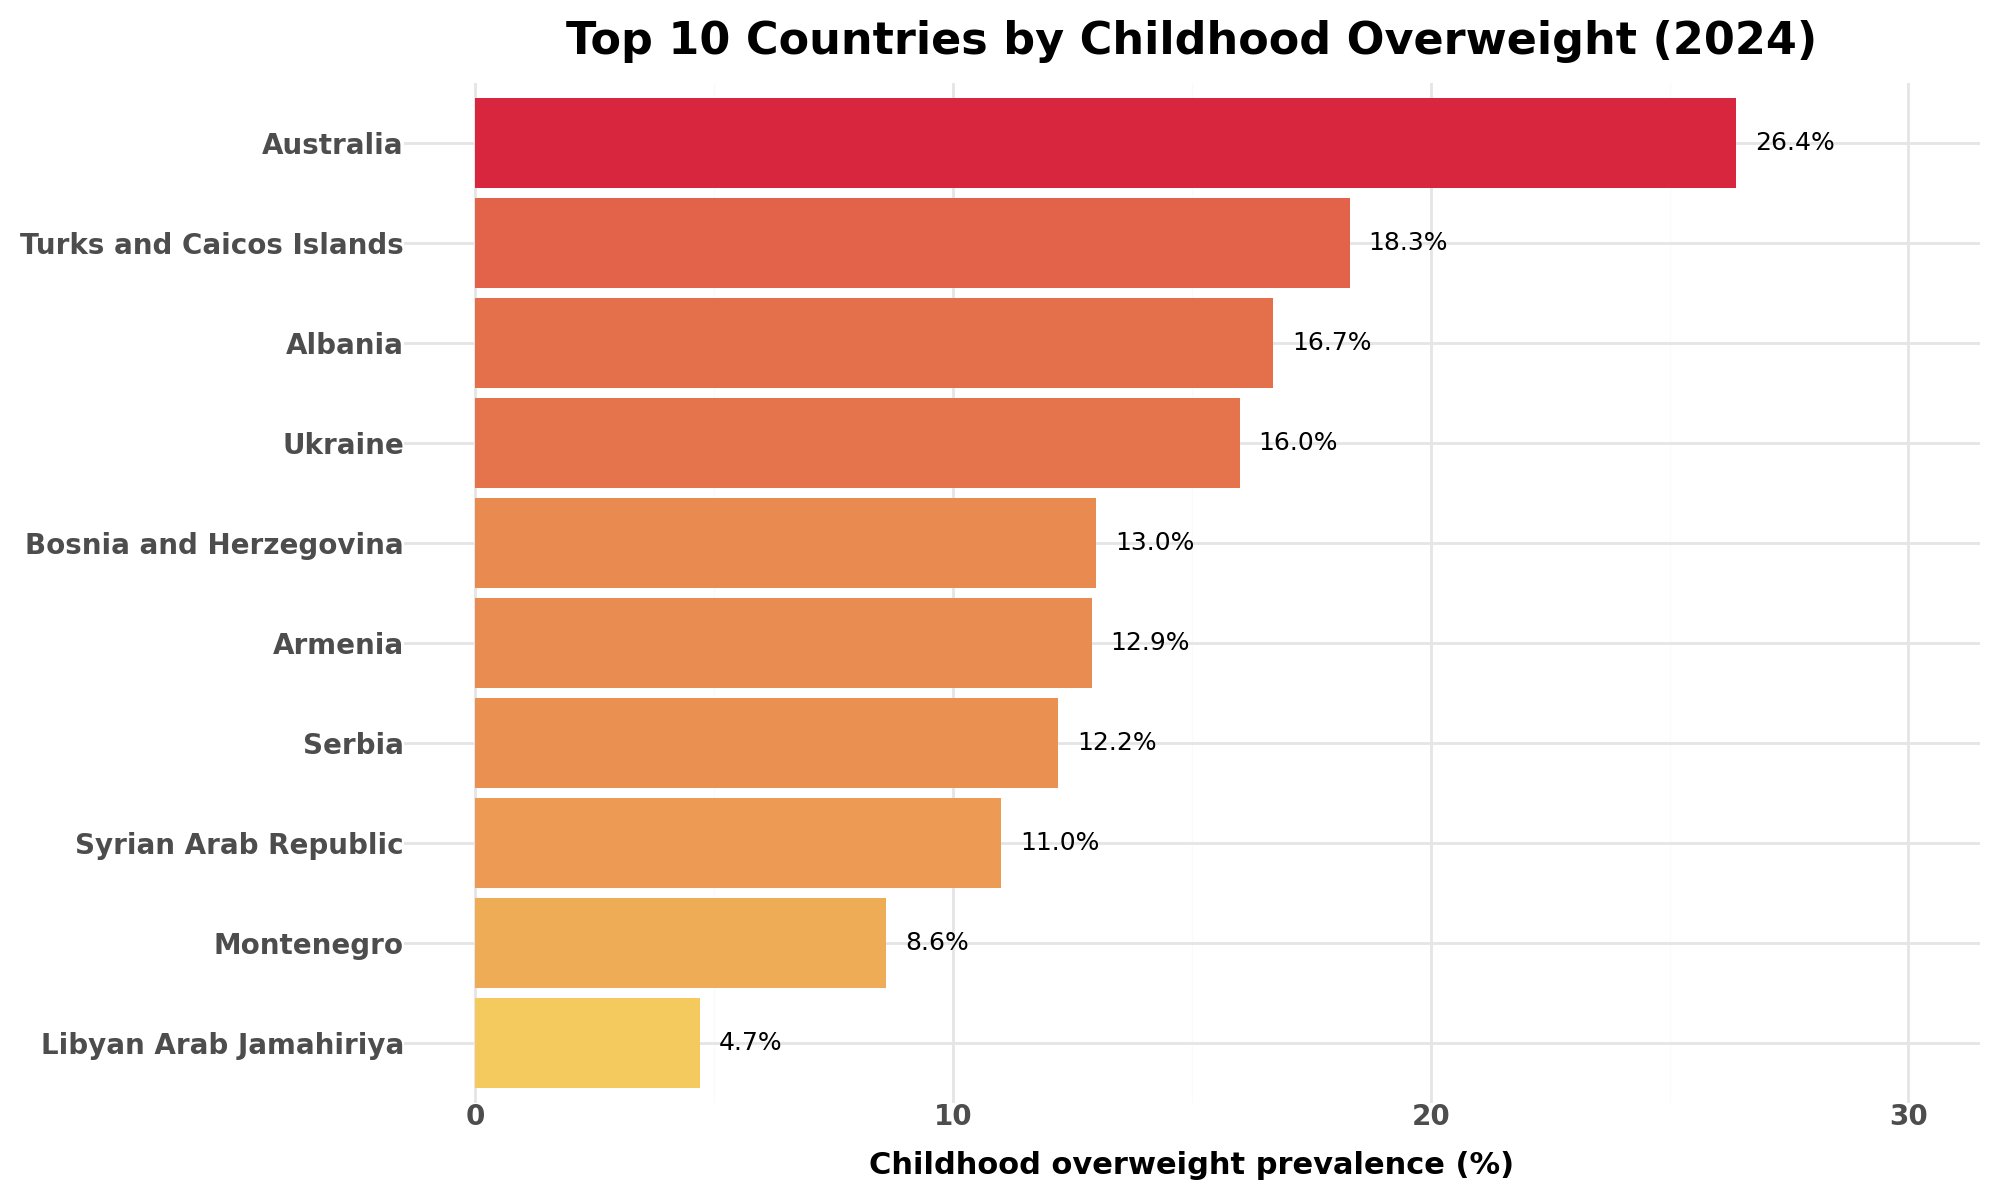

In [45]:
## TOP10 BAR CHART
(
    ggplot(top10, aes(x='reorder(country, value)', y='value', fill='value'))
    + geom_col()
    + geom_text(
        aes(label=top10['value'].round(1).astype(str) + '%'),
        ha='left',
        nudge_y=0.4,
        size=9
    )
    ## COLOURS
    + coord_flip()
    + scale_fill_gradient(low="#f4c95d", high="#d7263d")
    + scale_y_continuous(limits=[0, 30])
    + labs(
        title='Top 10 Countries by Childhood Overweight (2024)',
        x='',
        y='Childhood overweight prevalence (%)'
    )
    ## TEXT EDIT
    + theme_minimal()
    + theme(
        legend_position='none',
        figure_size=(10, 6),
        plot_title=element_text(weight='bold', size=16),
        axis_text_y=element_text(weight='bold', size=10),
        axis_text_x=element_text(weight='bold', size=10),
        axis_title_x=element_text(weight='bold', size=11)
    )
)

In [46]:
## GENDER ONLY TOTAL
df_total = overweight_df[overweight_df['sex'] == 'Total'].copy()

In [47]:
## Year's Average
trend = (
    df_total
    .groupby('year', as_index=False)
    .agg(avg_value=('value', 'mean'),
         n_countries=('country', 'nunique'))
)

display(trend.head())

,year,avg_value,n_countries
0,2000,6.710303,165
1,2001,6.858788,165
2,2002,6.997576,165
3,2003,7.110303,165
4,2004,7.189697,165


## **Global Trends in Childhood Overweight**

The global trend in childhood overweight between **2000 and 2024** shows some fluctuations over time, rather than a perfectly steady increase.

In the early 2000s, the average prevalence rises and reaches a peak around the mid-2000s. This is followed by a gradual decline until the late 2010s, after which the trend begins to increase again.

These fluctuations may be influenced by differences in data availability across countries, as well as changes in which countries report data in different years. As a result, the global average does not represent a perfectly consistent sample over time.

Despite these variations, the overall pattern suggests that childhood overweight remains a persistent global issue, with no sustained long-term decrease.

The recent increase towards 2024 may indicate that the problem is once again becoming more pronounced.

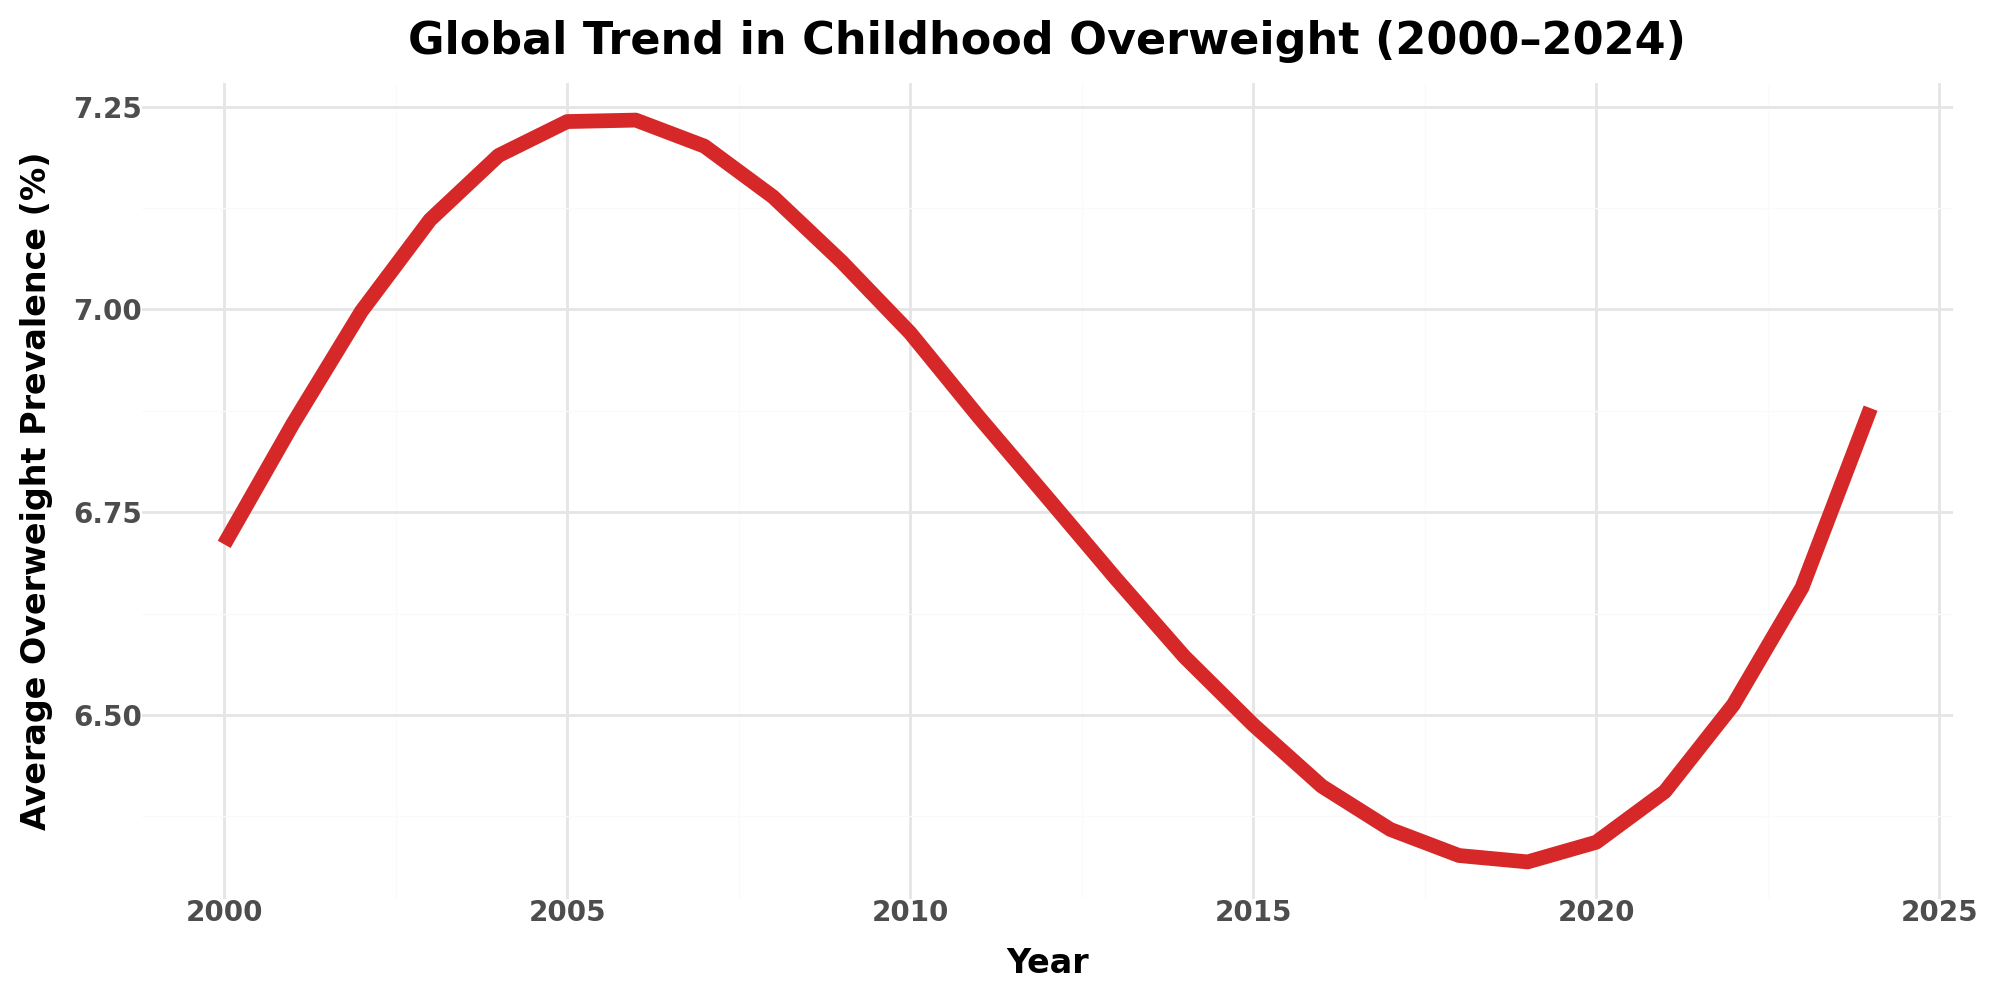

In [48]:
## Timeline Graph
(
    ggplot(trend, aes(x='year', y='avg_value'))

    # MAIN LINE
    + geom_line(color='#d62828', size=3.0)

    + labs(
        title='Global Trend in Childhood Overweight (2000–2024)',
        x='Year',
        y='Average Overweight Prevalence (%)'
    )

    + theme_minimal()

    + theme(
        figure_size=(10, 5),

        # TITLE
        plot_title=element_text(size=16, weight='bold'),

        # AXIS TITLES
        axis_title_x=element_text(size=12, weight='bold'),
        axis_title_y=element_text(size=12, weight='bold'),

        # AXIS TEXT (years and values)
        axis_text_x=element_text(size=10, weight='bold'),
        axis_text_y=element_text(size=10, weight='bold')
    )
)

In [49]:
df_2024 = overweight_df[
    overweight_df['year'] == 2024
].copy()

In [50]:
## Gender without total
gender_df = df_2024[
    df_2024['sex'].isin(['Male', 'Female'])
].copy()

In [51]:
## Male and Female columns filter
pivot_df = gender_df.pivot_table(
    index='country',
    columns='sex',
    values='value'
).reset_index()

pivot_df.head()

sex,country,Female,Male
0,Afghanistan,4.1,4.7
1,Albania,15.7,17.7
2,Algeria,12.5,14.2
3,Angola,4.4,5.1
4,Argentina,13.4,15.2


In [52]:
pivot_df = pivot_df.dropna()

In [53]:
##  GENDER DIFFERENCE
pivot_df['difference'] = pivot_df['Male'] - pivot_df['Female']

## **Gender Differences in Childhood Overweight**

The comparison between male and female childhood overweight shows that prevalence levels are very similar across countries.

Most observations lie close to the equality line, indicating that boys and girls are affected in a comparable way. While boys tend to have slightly higher values in some countries, the overall difference between genders remains small.

This suggests that childhood overweight is primarily driven by shared environmental and lifestyle factors, rather than strong gender-specific influences.

As a result, gender differences are not a major driver of variation in childhood overweight, and the analysis focuses more on geographic and temporal patterns.

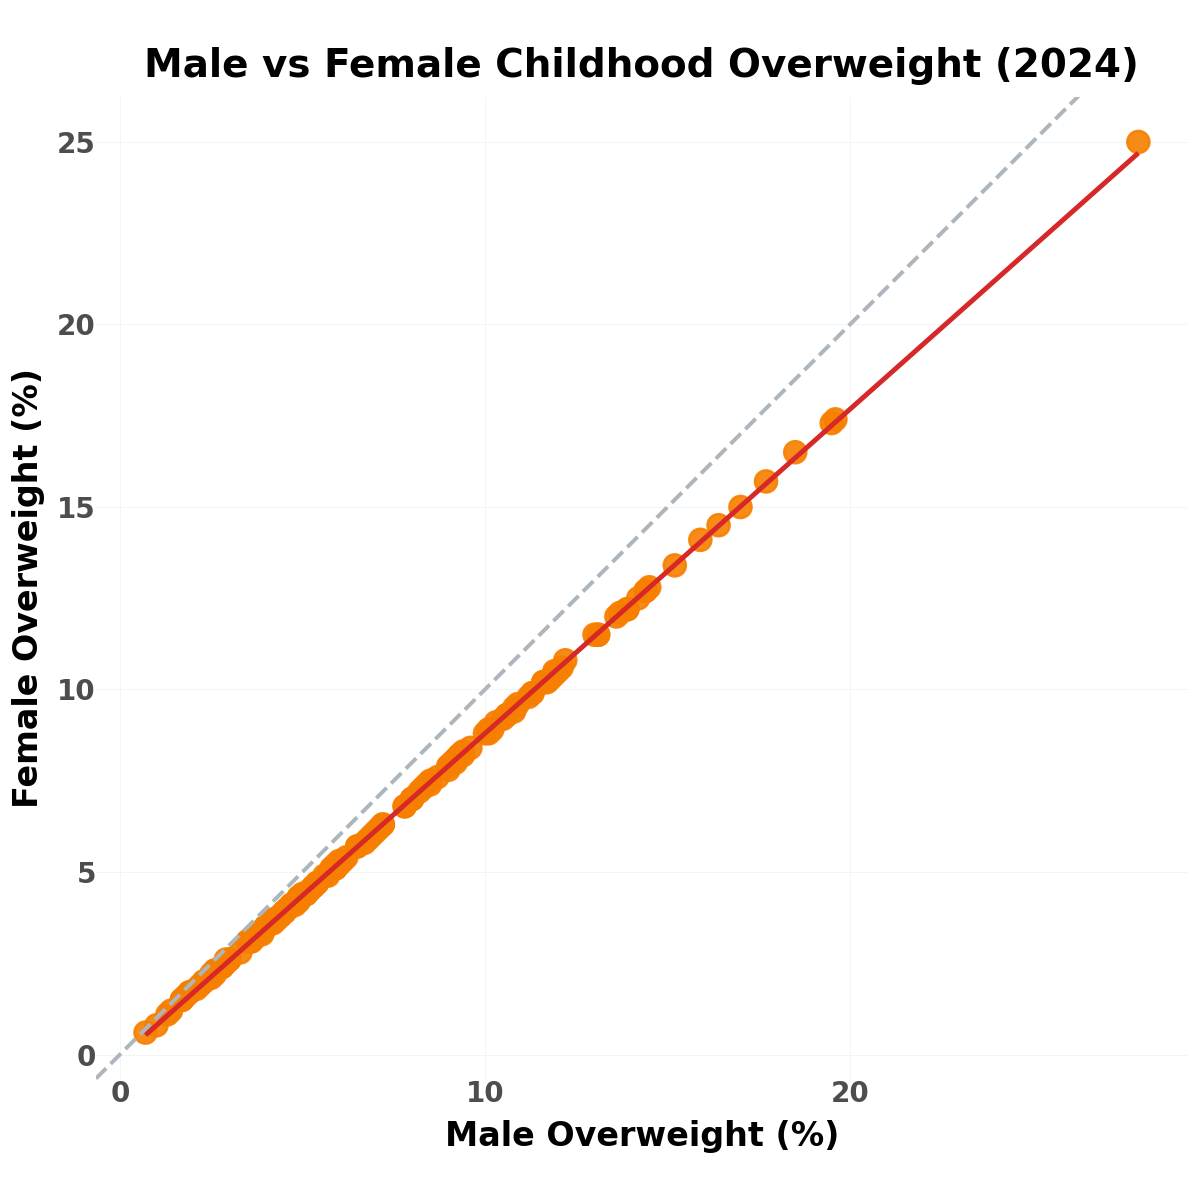

In [54]:
## Scatterplot Graph
(
    ggplot(pivot_df, aes(x='Male', y='Female'))

    # POINTS ON THE MAP
    + geom_point(color='#f77f00', size=4, alpha=0.9)

    # REGRESSION LINE
    + geom_smooth(method='lm', se=False, color='#d62828', size=1, alpha=0.3)

    # DIAGONAL LINE
    + geom_abline(slope=1, intercept=0, color='#adb5bd', linetype='dashed', size=0.8)

    + coord_equal()

    + labs(
        title='Male vs Female Childhood Overweight (2024)',
        x='Male Overweight (%)',
        y='Female Overweight (%)'
    )

    + theme_minimal()
    + theme(
        figure_size=(6, 6),

        # BOLD TEXT
        plot_title=element_text(size=14, weight='bold'),
        axis_title_x=element_text(size=12, weight='bold'),
        axis_title_y=element_text(size=12, weight='bold'),
        axis_text_x=element_text(size=10, weight='bold'),
        axis_text_y=element_text(size=10, weight='bold'),

        # GRID IN THE BACKGROUND
        panel_grid_major=element_line(color='#f1f3f5', size=0.3),
        panel_grid_minor=element_blank()
    )
)

**Conclusion**

---


The findings of this report show that childhood overweight is a significant and unevenly distributed global health challenge.

The map demonstrates that overweight prevalence varies considerably across countries and regions, with particularly high levels in Australia and selected countries in Latin America, North Africa, and Eastern Europe. The bar chart highlights the countries most affected within the selected comparison group, while the time-series analysis shows that childhood overweight remains a persistent issue over time. Finally, the gender comparison suggests that boys and girls are affected in broadly similar ways.

Overall, the analysis suggests that childhood overweight is shaped more strongly by geographic, social, and environmental factors than by gender alone. These patterns underline the importance of targeted public health strategies, improved nutrition, and greater support for healthy lifestyles in childhood.

Without continued action, childhood overweight is likely to remain a **major global concern** in the years ahead.